In [1]:
using Oceananigans
using NCDatasets
using Printf
using CairoMakie
using Oceananigans.Fields
using Oceananigans.AbstractOperations: volume
using NaNStatistics

In [2]:
using TopographicHorizontalConvection
using TopographicHorizontalConvection: HorizontalConvectionSimulation

In [3]:
ds_buoy = NCDataset(string("/pub/ikeshwan/code/HorizontalConvection/output/turbulent_h0.6_Ra1.0e8_coldstart_buoyancy.nc"));
ds_vel = NCDataset("/pub/ikeshwan/code/HorizontalConvection/output/turbulent_h0.6_Ra1.0e8_coldstart_velocities.nc");

# Calculation of Fluxes

#### Reversible Vertical Buoyancy Flux:  
$ \phi_z = \int \rho g w dV \rightarrow -\int b w dV $

#### Rate of conversion from internal to potential energy:   
$ \phi_i = -\kappa g A (\bar{\rho}_{top} - \bar{\rho}_{bottom})$

#### Rate of change of background potential due to diapycnal mixing : 
$ \phi_d = \kappa g \int - \frac{dz_*}{d \rho} \left | \nabla \rho \right |^2 dV$

In [4]:
#vertical buoyancy flux

b = ds_buoy["b"][4+1:end-4, :, 4+1:end-4, :];
w = ds_vel["w"][4+1:end-4, :, 5+1:end-4, :];

∫ϕz = ds_buoy["∫ϕz"][4+1:end-4, :, 4+1:end-4, :];

#bw = b .* w;

In [5]:
#define positional arrays

x = ds_buoy["xC"][4+1:end-4]; Nx = length(x);
y = ds_buoy["yC"][:]; Ny =  length(y)
z = ds_buoy["zC"][4+1:end-4]; Nz = length(z);

H = 1.0;
Ly = H/4;
Δy = Ly/Ny;

In [6]:
#integrate bw over volume -- reimann sum
time = ds_buoy["time"][:];

#bw = reshape(bw, Nx, Ny, Nz, length(time));

Δx = reshape(diff(ds_buoy["xF"])[4+1:end-4], Nx,1,1);
Δz = reshape(diff(ds_buoy["zF"])[4+1:end-4], 1, 1, Nz);
ΔA = Δx .* Δy;
ΔV = ΔA .* Δz;

In [8]:
ϕ_z = zeros(size(time,1));
for n in 1:size(time, 1)
    ∫ϕz_t = ∫ϕz[:, 1, :, n]
    wet = ∫ϕz_t.!=0
    ∫ϕz_t[.!wet] .= NaN
    ϕ_z[n] = nansum(
        ∫ϕz_t .*
        ΔV, 
        dims=(3)
        )[1,1,1]
end

ϕ_z

141-element Vector{Float64}:
 0.0
 6.821650327088413e-5
 6.848746540036408e-5
 3.665576364980555e-5
 7.274410209554458e-5
 7.491749362766541e-5
 7.202277969460011e-5
 6.37743467759908e-5
 5.3288774568536774e-5
 6.992014144109613e-5
 5.274910238459716e-5
 5.6098670898777116e-5
 4.472610910821834e-5
 ⋮
 3.0395800018782618e-5
 3.5259444206911606e-5
 4.6594972661959474e-5
 5.0062291687677595e-5
 1.0628951762460752e-5
 3.462929129306311e-5
 3.984538235915337e-5
 2.676870542301654e-5
 4.2018011789545905e-5
 4.433558879187873e-5
 5.321497272913967e-5
 8.750363115284774e-6

### Next, let's calculate $\phi_i$

#### Rate of conversion from internal to potential energy:   
$ \phi_i = -\kappa g A (\bar{\rho}_{top} - \bar{\rho}_{bottom}) \rightarrow \kappa A (b_{top} - b_{bottom}) $

In [9]:
b_bottom = TopographicHorizontalConvection.buoyancy_level_avg(ds_buoy, "bottom");
b_top = TopographicHorizontalConvection.buoyancy_level_avg(ds_buoy, "top");
#I cant seem to figure out how to access global attributes from NetCDF files, but upon looking at ds_buoy we know kappa=0.0001
κ = ds_buoy.attrib["κ"];
A = 8

ϕᵢ = (κ * A) .* (b_top .- b_bottom);

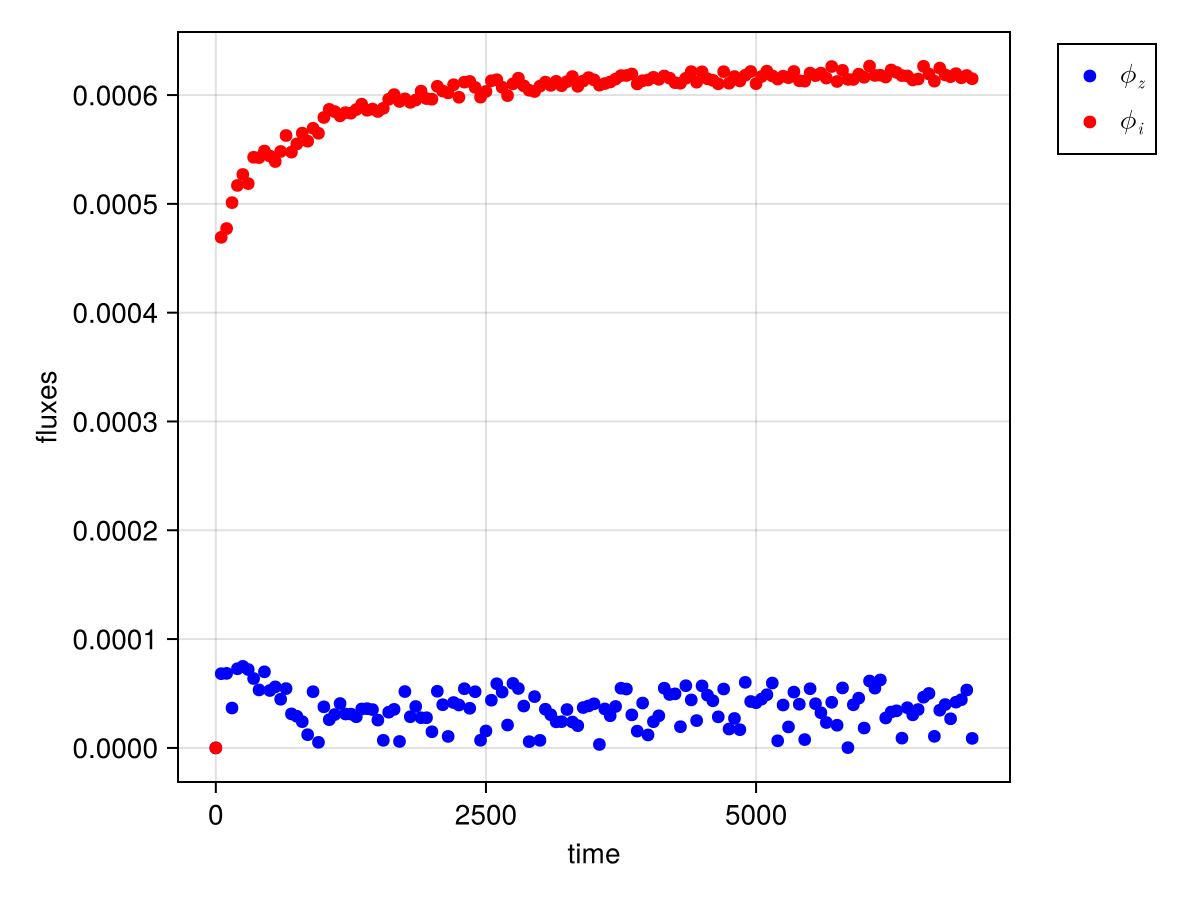

In [10]:
f = Figure()
ax = Axis(f[1,1], xlabel = "time", ylabel= "fluxes")
scatter!(ax, time, ϕ_z, color = "blue", label = L"\phi_z")
scatter!(ax, time, ϕᵢ, color = "red", label = L"\phi_i")
f[1,2] = axislegend()
f

### Now for $ \phi_d $

#### Rate of change of background potential due to diapycnal mixing : 
$ \phi_d = \kappa g \int - \frac{dz_*}{d \rho} \left | \nabla \rho \right |^2 dV$

#### Method:

first, we need to calculate the flattened 1D arrays for z and b.
to find $z_*$ we need to sort through z and b. Refer to the background_potential_energy.ipynb notebook. 

In [11]:
#so we already have x, z, Δx, and Δz defined above

#since this is a cold start sim, we can use the initial timestep to create wet map
#because buoyancy is not initialized as zero everywhere! cool!
b = ds_buoy["b"][4+1:end-4, 1, 4+1:end-4, 1];
wet = b.!=0.

b[.!wet] .= NaN; #wherever the buoyancy is zero == hills == land == NaN

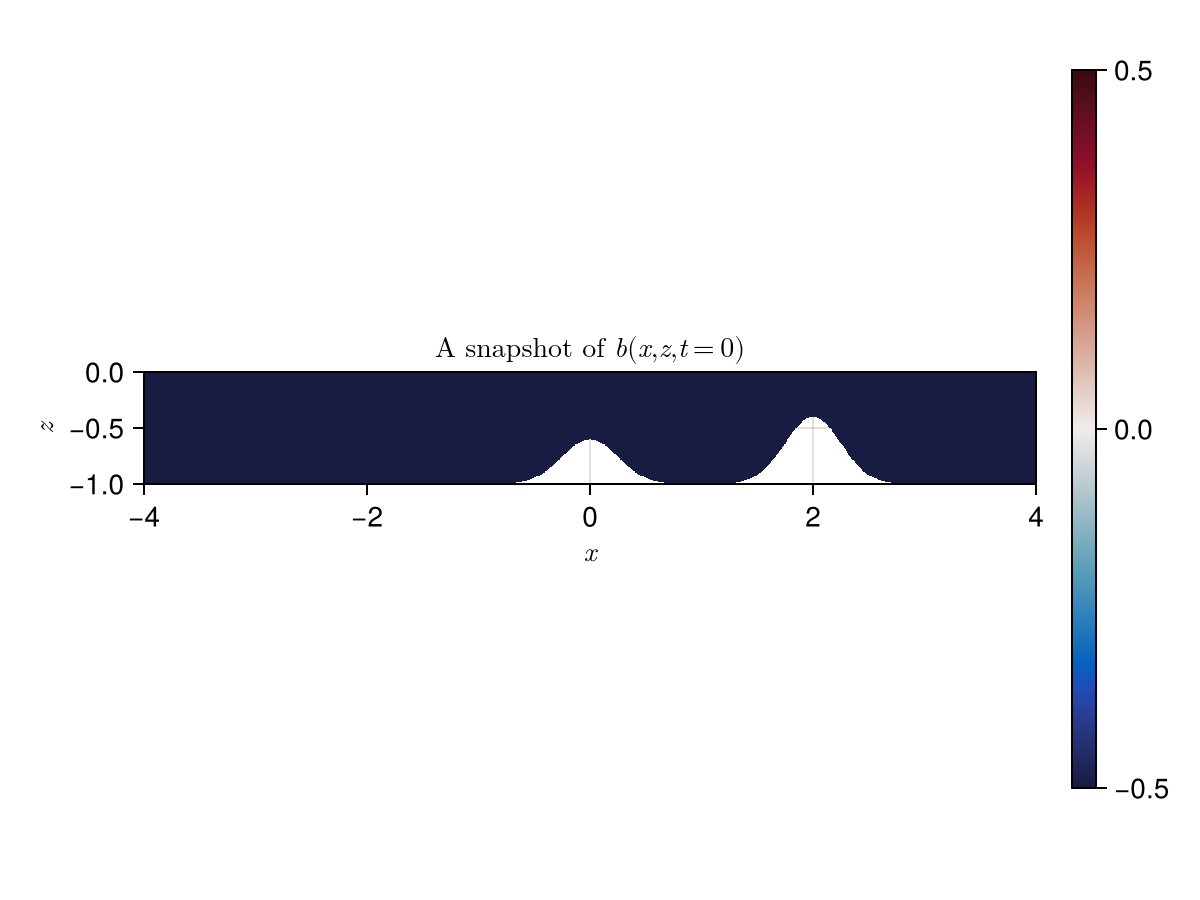

In [12]:
#okay lets plot a quick heatmap and see if that worked
#we should expect the buoyancy to be 0.5 everywhere and the hills to show up

f = Figure()
ax = Axis(f[1,1], aspect =8, xlabel = L"x", ylabel=L"z", title=L"\text{A snapshot of } b(x,z,t=0)")
hm = heatmap!(ax, x, z, b, colorrange=(-0.5, 0.5), colormap = :balance)
Colorbar(f[1,2], hm)
f

In [13]:
#okay z is already defined above, so now lets define z2d

z_3d = repeat(reshape(z, 1, 1, Nz), Nx, 1, 1);
b_flat = reshape(b, (Nx*Nz));
wet_flat = reshape(wet, (Nx*Nz));
z_flat = reshape(z_3d, (Nx*Nz));

In [14]:
#sort_idx is an array of indices that represents the sorted state of b_flat array
sort_idx = sortperm(b_flat);

#if we parse sort_idx through b_flat and z_flat then we get the SORTED b and z arrays

b_sorted, z_sorted = b_flat[sort_idx], z_flat[sort_idx];

In [37]:
size(b_sorted)

(113169,)

In [28]:
#] add Interpolations

In [15]:
size(wet.*ΔA[:,1,:])

(951, 119)

In [16]:
#now we can reconstruct z* 
using Interpolations

ΔV_flat = ΔV[sort_idx];
size(ΔA)

A_wet = dropdims(sum(wet.*ΔA[:,1,:], dims=(1)), dims=(1));

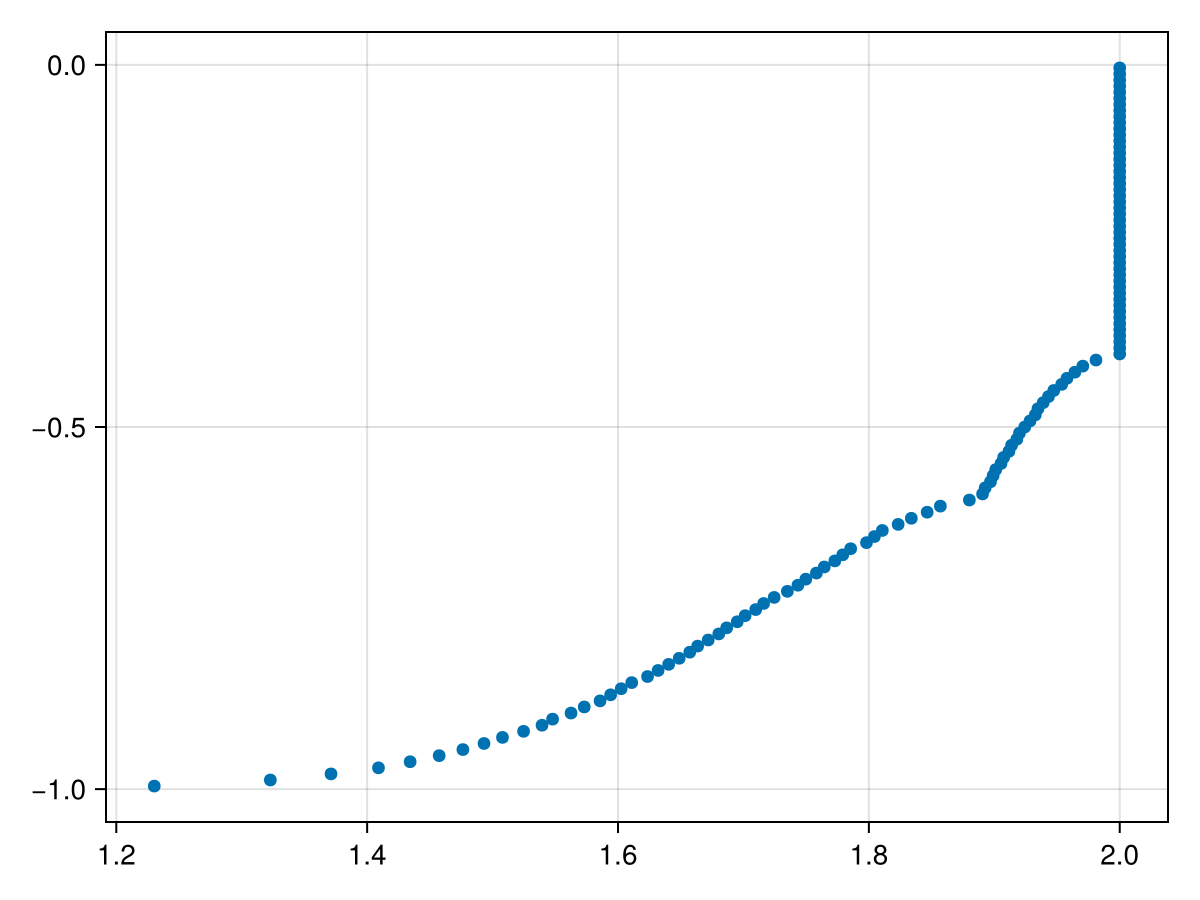

In [17]:
plot(A_wet, z)

In [24]:
A_interpolation = linear_interpolation(z, A_wet[:], extrapolation_bc=Line());

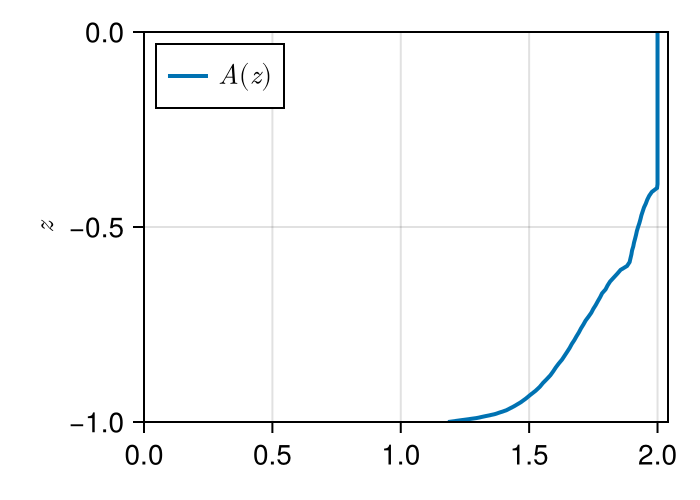

In [25]:
f_A = Figure(size=(350,250))
ax = Axis(f_A[1,1], ylabel=L"z", limits=((0, nothing), (-1,0)))
l = lines!(ax, A_interpolation(-1:0.01:0), collect(-1:0.01:0), linewidth=2, label=L"A(z)")
axislegend(ax, position=:lt)
f_A

In [26]:
z_bot = ds_buoy["zF"][5]
zstar_flat = zeros(size(b_sorted))
zstar_flat[1] = z_bot
for k in 2:length(b_sorted)
    A = A_interpolation(zstar_flat[k-1])
    if !isnan(b_sorted[k])
        zstar_flat[k] = zstar_flat[k-1] + ΔV_flat[k]/A
    else
        zstar_flat[k] = NaN
    end
end

### Next steps for Energy Flux Analysis

$ \phi_i = -\kappa g A (\bar{\rho}_{top} - \bar{\rho}_{bottom}) \rightarrow \kappa A (b_{top} - b_{bottom}) $

This isn't quite right, we can't use A=8 for this because the hills complicate things. So, in order to close the energy budget, the best course of action right now is to go back to NO topography. This will simplify the problem, until we are ready to go back to topography. 